# End-to-End Time Series Forecasting (Feature Engineering + LightGBM)

https://www.kaggle.com/competitions/playground-series-s5e1/overview

Target: Root Mean Squared Logarithmic Error (RMSLE)

$$
RMSLE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left( \log(1 + \hat{y}_i) - \log(1 + y_i) \right)^2 }
$$

## 1. Import libraries and Data

In [72]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Estatística para Time Series
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Machine Learning
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_log_error

def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

# Modelos
from lightgbm import LGBMRegressor
from lightgbm import early_stopping, log_evaluation
import lightgbm as lgb

# Otimização
import optuna

# Saving files
import json

In [4]:
path = r"C:\Users\evert\anaconda_projects\0011 - Store Sales - Time Series Forecasting"

df = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")
df_submission = pd.read_csv("sample_submission.csv")

## 2. Exploring the Dataset and Preparing for Modeling

In [5]:
df.shape

(230130, 6)

In [6]:
df.dtypes

id            int64
date         object
country      object
store        object
product      object
num_sold    float64
dtype: object

In [7]:
df.head(5)

,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


Issues:

1. The 'date' column is of type object, so we need to convert it to datetime.
2. The 'num_sold' column has NaN values. NaN values on some dates mean there were no sales on those dates. We cannot remove them; the best approach is to convert them to 0.

In [8]:
# Converting 'date' to date type
df['date'] = pd.to_datetime(df['date'])
df_test['date'] = pd.to_datetime(df_test['date'])

In [9]:
# converting NaN to zero in 'num_sold' column
df["num_sold"] = df["num_sold"].fillna(0)

In [10]:
df.isna().sum()

id          0
date        0
country     0
store       0
product     0
num_sold    0
dtype: int64

Below, we are seeing the number of distinct values and the values of the columns `country`, `store` and `product`

In [11]:
print("Country values:", df["country"].nunique(), sorted(df["country"].unique()), "\n")

print("Store values:", df["store"].nunique(), sorted(df["store"].unique()), "\n")

print("Product values:", df["product"].nunique(), sorted(df["product"].unique()), "\n")

Country values: 6 ['Canada', 'Finland', 'Italy', 'Kenya', 'Norway', 'Singapore'] 

Store values: 3 ['Discount Stickers', 'Premium Sticker Mart', 'Stickers for Less'] 

Product values: 5 ['Holographic Goose', 'Kaggle', 'Kaggle Tiers', 'Kerneler', 'Kerneler Dark Mode'] 



Now, we are going to analyse our traget variable `num_sold`. By putting it on a graph, we can see if there are any sazonality

In [12]:
sales_by_date = df.groupby("date")["num_sold"].sum()

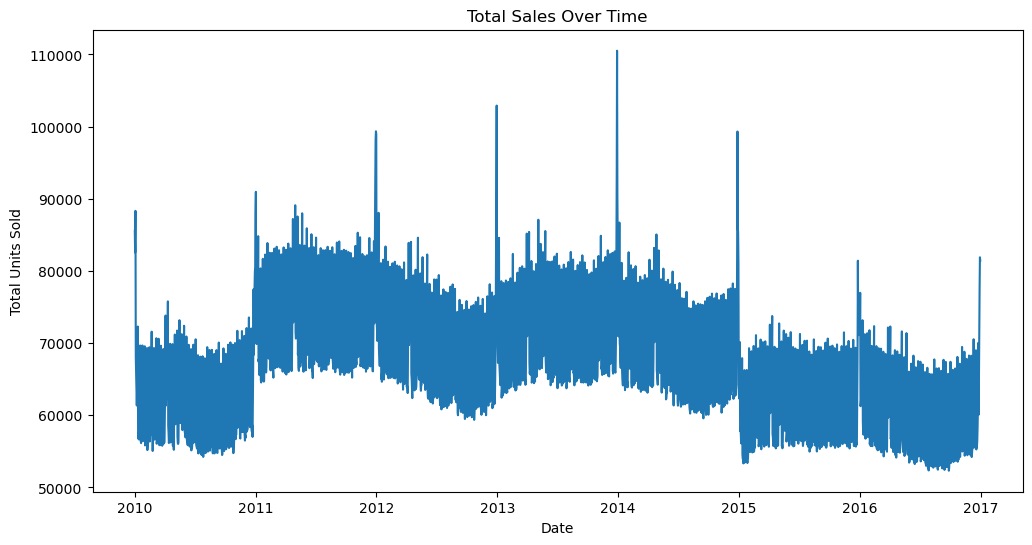

In [13]:
plt.figure(figsize=(12,6))
plt.plot(sales_by_date.index, sales_by_date.values)
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Units Sold")
plt.show()

## 3. Feature Engineering (time, lag, rolling)

Extracting basic time features

In [14]:
# Creating a combined dataset (df + df_test) for feature engineering
full = pd.concat([df, df_test], sort=False)

In [15]:
# Creating time features
full["year"] = full["date"].dt.year
full["month"] = full["date"].dt.month
full["day"] = full["date"].dt.day
full["dayofweek"] = full["date"].dt.dayofweek
full["weekofyear"] = full["date"].dt.isocalendar().week.astype(int)
full["quarter"] = full["date"].dt.quarter
full["is_weekend"] = full["dayofweek"].isin([5, 6]).astype(int)

Extracting lag features (the code below create lag_1, 7, 14, 28 on the original dataframe

In [16]:
full["lag_1"] = df.groupby(["country", "store", "product"])["num_sold"].shift(1)
full["lag_7"] = df.groupby(["country", "store", "product"])["num_sold"].shift(7)
full["lag_14"] = df.groupby(["country", "store", "product"])["num_sold"].shift(14)
full["lag_28"] = df.groupby(["country", "store", "product"])["num_sold"].shift(28)

Get dummies to our categorical features

In [17]:
full = pd.get_dummies(
    full,
    columns=["country", "store", "product"],
    drop_first=False
)

In [18]:
full.head(5)

,id,date,num_sold,year,month,day,dayofweek,weekofyear,quarter,is_weekend,...,country_Norway,country_Singapore,store_Discount Stickers,store_Premium Sticker Mart,store_Stickers for Less,product_Holographic Goose,product_Kaggle,product_Kaggle Tiers,product_Kerneler,product_Kerneler Dark Mode
0,0,2010-01-01,0.0,2010,1,1,4,53,1,0,...,False,False,True,False,False,True,False,False,False,False
1,1,2010-01-01,973.0,2010,1,1,4,53,1,0,...,False,False,True,False,False,False,True,False,False,False
2,2,2010-01-01,906.0,2010,1,1,4,53,1,0,...,False,False,True,False,False,False,False,True,False,False
3,3,2010-01-01,423.0,2010,1,1,4,53,1,0,...,False,False,True,False,False,False,False,False,True,False
4,4,2010-01-01,491.0,2010,1,1,4,53,1,0,...,False,False,True,False,False,False,False,False,False,True


In [19]:
# Split full into df and df_test again
df = full[full["num_sold"].notna()]
df_test = full[full["num_sold"].isna()]

## 4. Time-Based Split

In time series we cannot shuffle the data, if we shuffle it, the model will train with future data, which cause leakage

In [20]:
# Ensure the data is sorted
df = df.sort_values("date")

In [35]:
# I used a two-year training window to capture yearly seasonality patterns in the data.

split_date = "2012-01-01"

train_df = df[df["date"] < split_date]
valid_df = df[df["date"] >= split_date]

## 5. Creating the model

In [36]:
# Defining feature set and splitting data into X (predictors) and y (target) for train and validation
features = [col for col in df.columns if col not in ["num_sold", "date"]]

X_train = train_df[features]
y_train = train_df["num_sold"]

X_valid = valid_df[features]
y_valid = valid_df["num_sold"]

In [37]:
# Initializing and fitting a LightGBM model with early stopping and validation monitoring
model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(50),
        log_evaluation(100)
    ]
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001346 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1419
[LightGBM] [Info] Number of data points in the train set: 65700, number of used features: 26
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 735.255586
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 69.8541	valid_0's l2: 4879.59
Early stopping, best iteration is:
[92]	valid_0's rmse: 69.2976	valid_0's l2: 4802.16


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [53]:
# Predicting target values using the validation dataset
y_pred = model.predict(X_valid)
y_pred = np.clip(y_pred, 0, None)

val_rmsle = rmsle(y_valid, y_pred)
print("Validation RMSLE:", val_rmsle)

Validation RMSLE: 0.5579352876246106


In [39]:
# Computing RMSE to evaluate model performance on the validation set
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print("Validation RMSE:", rmse)

Validation RMSE: 69.29763350756325


## 6. Hyperparameters Tuning

In [47]:
def objective(trial):

    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "verbosity": -1,
        
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
    }

    model = lgb.LGBMRegressor(
        **params,
        n_estimators=1000
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(50, verbose=False)
        ]
    )

    preds = model.predict(X_valid)
    preds = np.clip(preds, 0, None) #it's important, because RMSLE don't work with values <= -1
    
    return rmsle(y_valid, preds)

In [48]:
study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=25)

print("Best RMSLE:", study.best_value)
print("Best parameters:", study.best_params)

[I 2026-03-03 09:12:05,818] A new study created in memory with name: no-name-e196ceb8-5c58-4e50-8d39-94bd5e6ed897
[I 2026-03-03 09:12:07,788] Trial 0 finished with value: 0.4753508096986734 and parameters: {'learning_rate': 0.05549064610752902, 'num_leaves': 71, 'max_depth': 11, 'min_child_samples': 97, 'feature_fraction': 0.8344025278316302, 'subsample': 0.945406546780099}. Best is trial 0 with value: 0.4753508096986734.
[I 2026-03-03 09:12:08,884] Trial 1 finished with value: 0.55985146334293 and parameters: {'learning_rate': 0.0487293519532884, 'num_leaves': 63, 'max_depth': 3, 'min_child_samples': 81, 'feature_fraction': 0.8783938907444915, 'subsample': 0.7794360667936746}. Best is trial 0 with value: 0.4753508096986734.
[I 2026-03-03 09:12:10,077] Trial 2 finished with value: 0.6096970541596731 and parameters: {'learning_rate': 0.09706886558462406, 'num_leaves': 58, 'max_depth': 8, 'min_child_samples': 12, 'feature_fraction': 0.7882009124047206, 'subsample': 0.7622045719868733}. B

Best RMSLE: 0.41752279511377033
Best parameters: {'learning_rate': 0.09870939065659294, 'num_leaves': 45, 'max_depth': 9, 'min_child_samples': 88, 'feature_fraction': 0.9128098561573368, 'subsample': 0.8028096391231491}


In [74]:
# Saving the best_params
with open("best_params.json", "w") as f:
    json.dump(best_params, f)

In [52]:
best_params = study.best_params
best_params.update({
    "objective": "regression",
    "metric": "rmse",
    "boosting_type": "gbdt",
    "verbosity": -1
})

print("Best RMSLE:", study.best_value)
print("Best parameters:", best_params)

Best RMSLE: 0.41752279511377033
Best parameters: {'learning_rate': 0.09870939065659294, 'num_leaves': 45, 'max_depth': 9, 'min_child_samples': 88, 'feature_fraction': 0.9128098561573368, 'subsample': 0.8028096391231491, 'objective': 'regression', 'metric': 'rmse', 'boosting_type': 'gbdt', 'verbosity': -1}


In [54]:
model_final = lgb.LGBMRegressor(
    **best_params,
    n_estimators=1000
)

## 7. Training the Model on the Full Dataset

In [65]:
# Defining the final feature set excluding target and non-predictive columns
features = [col for col in df.columns if col not in ["num_sold", "date", "id"]]

In [66]:
# Creating full training feature matrix (X_full) and target vector (y_full)
X_full = df[features]
y_full = df["num_sold"]

In [67]:
# Initializing the final LightGBM model with optimized hyperparameters
model_final = lgb.LGBMRegressor(
    **best_params,
    n_estimators=1000
)

In [68]:
# Training the tuned model on the complete training dataset
model_final.fit(X_full, y_full)

,boosting_type,'gbdt'
,num_leaves,45
,max_depth,9
,learning_rate,0.09870939065659294
,n_estimators,1000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,88


In [69]:
# Preparing the test feature matrix for final inference
X_test = df_test[features]

In [70]:
# Generating final predictions and ensuring non-negative outputs
y_test = model_final.predict(X_test)
y_test = np.clip(y_test, 0, None)

In [71]:
# Building and exporting the competition submission file
submission = pd.DataFrame({
    "id": df_test["id"],
    "num_sold": y_test
})

submission.to_csv("submission.csv", index=False)

## 7. Final Discussion

In [78]:
comparison = pd.DataFrame({
    "Model": ["Baseline LightGBM", "Tuned LightGBM (Optuna)"],
    "RMSLE": [val_rmsle, study.best_value]
})

comparison

,Model,RMSLE
0,Baseline LightGBM,0.557935
1,Tuned LightGBM (Optuna),0.417523


In [79]:
improvement = (val_rmsle - study.best_value) / val_rmsle * 100

print(f"Relative improvement: {improvement:.2f}%")

Relative improvement: 25.17%


### Impact of Hyperparameter Optimization

The baseline LightGBM model already delivered solid performance due to:

- A proper time-based validation split  
- Well-structured temporal feature engineering  
- Early stopping to reduce overfitting  

However, the Optuna-based hyperparameter optimization further improved the model’s generalization capacity.

By tuning key parameters such as:

- **`num_leaves`**  _Controls the maximum number of leaves in one tree. Higher values increase model complexity and allow the model to capture more intricate patterns, but may increase the risk of overfitting._
- **`max_depth`**  _Limits the maximum depth of each tree. Constraining depth helps control model complexity and reduces overfitting, especially in noisy datasets._
- **`learning_rate`** _Determines how much each new tree contributes to the overall model. Lower values improve stability and generalization but require more trees to converge._
- **`min_child_samples`** _Specifies the minimum number of samples required in a leaf node. Larger values make the model more conservative and help prevent overfitting._
- **`feature_fraction`** _Fraction of features randomly selected for each tree. Introduces randomness that can improve generalization and reduce variance._
- **`subsample`** _Fraction of training data used for each boosting iteration. Helps reduce overfitting by adding stochasticity to the training process._

the model achieved a better balance between bias and variance, leading to a lower RMSLE on the validation set.

This improvement highlights how structured hyperparameter search can meaningfully enhance performance, even when starting from a strong baseline.

---

### Why LightGBM?

LightGBM was selected for both theoretical and practical reasons:

1. **Computational Efficiency**  
   Its histogram-based learning algorithm enables fast training and scalability.

2. **Strong Performance on Tabular Data**  
   Gradient boosting methods are highly effective for structured datasets such as retail sales data.

3. **Ability to Capture Non-Linear Interactions**  
   Time series forecasting often involves complex interactions between temporal features, which tree-based models handle naturally.

4. **Minimal Preprocessing Requirements**  
   LightGBM does not require feature scaling, simplifying the modeling pipeline.

---

### Final Considerations

This notebook demonstrates:

- Proper time-based validation methodology  
- Feature engineering for temporal structure  
- Baseline benchmarking  
- Targeted hyperparameter optimization  
- Reproducibility through parameter persistence  

Future improvements could include:

- TimeSeries cross-validation  
- Feature importance analysis  
- Ensemble strategies  
- Additional lag and rolling window features  
- Model stacking with other gradient boosting frameworks